# Stock

# import

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import t

import yfinance as yf
import datetime as dt

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split


import random
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import kurtosis
from scipy.stats import t
from scipy.stats import norm


# Config

In [2]:
class config:    
    train_n = 80
    test_n = 20
    seed = 111
    n_samples = train_n+test_n
    train_prob = 0.8
    n_1 = 0.05 
    Bootstrap = 100

# Input Data

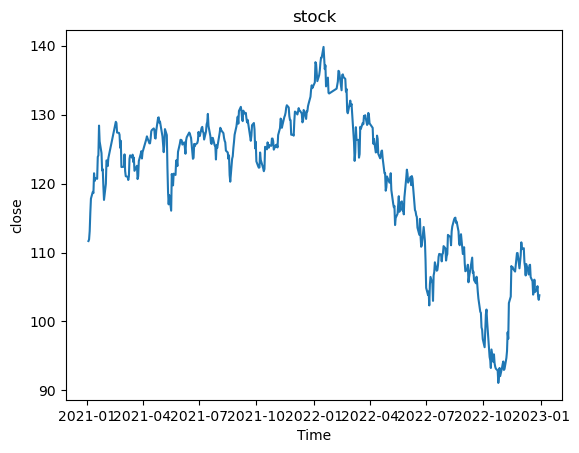

489

In [3]:
# 0050
stock = '0050.TW'  

# 開始時間
start = dt.datetime.strptime("20210101","%Y%m%d")

# 結束時間
end = dt.datetime.strptime("20230101","%Y%m%d")

df_stock = yf.Ticker(stock).history(start=start ,end=end) 
df_stock = df_stock.dropna()


plt.plot(df_stock['Close'])
plt.xlabel('Time')
plt.ylabel('close')
plt.title('stock')
plt.show()

len(df_stock)

In [4]:
# kalman-filter

def kalman_filter(observations):
    # 初始化卡爾曼濾波器的參數
    initial_estimate = observations[0]  # 初始狀態估計
    initial_estimate_error = 1  # 初始估計的不確定性
    process_variance = 0.5  # 系統模型的不確定性（系統噪聲方差） 
    measurement_variance = 10  # 觀測模型的不確定性（觀測噪聲方差）

    # 初始化卡爾曼濾波器估計
    estimated_state = initial_estimate
    estimate_error = initial_estimate_error

    # 存儲估計值的歷史
    estimated_states = []
    
    # 存儲errors的歷史
    estimate_errors = []

    # 開始卡爾曼濾波過程
    for measurement in observations:
        # 預測步驟
        predicted_state = estimated_state
        predict_error = estimate_error + process_variance

        # 更新步驟
        kalman_gain = predict_error / (predict_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1 - kalman_gain) * predict_error

        estimated_states.append(estimated_state)
        estimate_errors.append(estimate_error)
  
    return estimated_states

# MA

def MA_filter(observations,n):
    # MA_filter會損失n-1個樣本
    MA_filter = np.convolve(observations, np.ones(n)/n, mode='valid')  
    
    return MA_filter



def seed_everything(seed):
    # Set NumPy random seed
    np.random.seed(seed)
    
    # Set Python random seed
    random.seed(seed)
    
    tf.random.set_seed(seed)
    
# 製造滯後數據
def create_dataset(dataset,look_back):
    X, Y = [], []
    for i in range(len(dataset)-look_back):
        X.append(dataset[i:(i+look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)


# 在ARIMA(p,0,q)，p=0,...,5，q=0,...,5，找AIC最小的model
def find_order(dataset):
    # p，q取太大的話會出現 LinAlgError: LU decomposition error.
    p_range = range(0, 5)  # AR
    q_range = range(0, 5)  # MA

    best_aic = np.inf
    best_params = None

    # 進行參數搜索
    for p in p_range:
        for q in q_range:
            # print(p,q)
            if p or q != 0:
                if (p,q)!= (2,0):
                    model = ARIMA(dataset, order=(p, 0, q))
                    results = model.fit()
                    aic = results.aic
                    if aic < best_aic:
                        best_aic = aic
                        best_params = (p, q)

    return best_params

---
# kalman_filter ARIMA ANN model
---
# build kalman_filter model
### 用ARIMA的AR部分的兩倍當作ANN的window size
ARIMA的細節:
用BIC去選參數pq，最高設pq要小於5

ANN的細節:
AR部分的n倍當作ANN的window size

# dataset

In [5]:
df_stock=np.array(df_stock['Close'])

In [6]:
# 0050

# Linear
K_Linear_df_stock = kalman_filter(df_stock)
# non_Linear
K_non_Linear_df_stock = df_stock - K_Linear_df_stock


# 切訓練測試
train_prob = config.train_prob

K_Linear_train_stock = K_Linear_df_stock[0:int(train_prob*len(df_stock))]
K_Linear_test_stock = K_Linear_df_stock[int(train_prob*len(df_stock)):len(df_stock)]

K_non_Linear_train_stock = K_non_Linear_df_stock[0:int(train_prob*len(df_stock))]    
K_non_Linear_test_stock = K_non_Linear_df_stock[int(train_prob*len(df_stock)):len(df_stock)]

test_stock = df_stock[int(train_prob*len(df_stock)):len(df_stock)]

In [7]:
K_non_Linear_df_stock

array([ 0.00000000e+00,  1.90179870e-01,  1.16596866e+00,  3.13059164e+00,
        4.22640812e+00,  4.21656778e+00,  3.25211562e+00,  4.92257971e+00,
        3.04880380e+00,  2.76744172e+00,  2.14463769e+00,  4.26929753e+00,
        3.59677867e+00,  6.32773427e+00,  3.22766687e+00,  1.22428152e+00,
       -1.03933622e+00, -6.84690719e-01, -2.52978891e+00, -3.60216125e+00,
       -1.00988001e+00,  1.90814662e+00,  1.45311235e+00,  5.75260494e-01,
        1.37778358e+00,  5.32309039e+00,  4.11166221e+00,  2.18823855e+00,
        1.71387275e+00,  1.15089585e+00, -5.84117397e-01,  3.40189027e-01,
       -2.77422957e+00, -2.18267721e+00, -3.14720874e-01, -2.19703431e+00,
       -2.34488333e+00, -1.94929535e+00, -1.92648341e+00, -1.13743917e+00,
        1.14540145e+00,  1.32008093e+00,  7.99125045e-01,  9.69640612e-01,
       -6.84830667e-02,  4.59068527e-01, -1.17425519e+00, -4.98992774e-01,
       -2.52380254e-01, -1.74342642e+00, -1.06441887e+00,  9.10214171e-01,
        1.53562983e+00,  

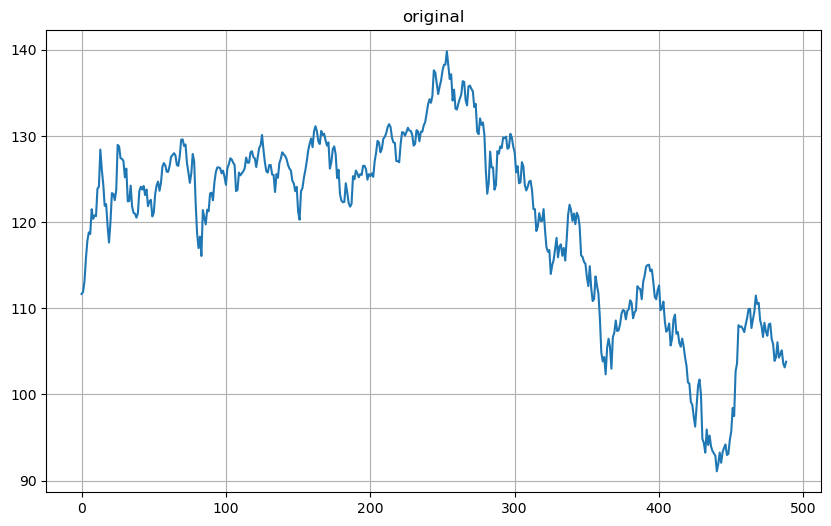

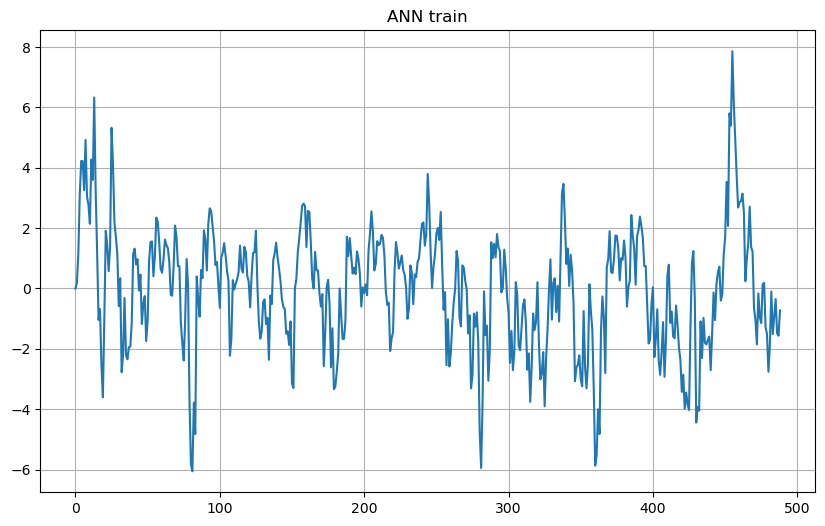

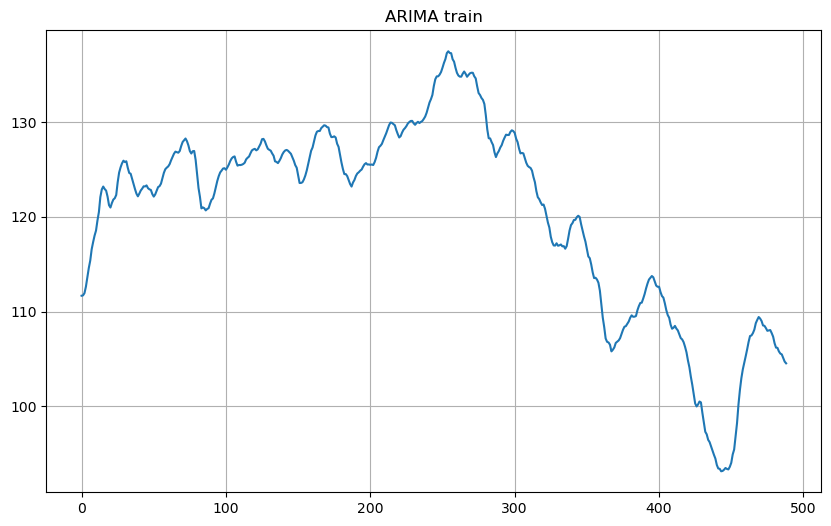

In [8]:
# 檢查丟入ANN的數據 以及綠波過後的數據
plt.figure(figsize=(10, 6))
plt.plot(df_stock)
plt.title('original')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(K_non_Linear_df_stock)
plt.title('ANN train')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(K_Linear_df_stock)
plt.title('ARIMA train')
plt.grid(True)
plt.show()

In [35]:
# 用ARIMA預測 Linear part選擇期數

order = find_order(K_Linear_train_stock)
order

C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: M

(2, 0)

In [36]:
# 用ARIMA預測 Linear part
K_AR_y_pred_stock = []
K_AR_y_pred_stock_CI = []
for i in range(0, len(df_stock)-int(train_prob*len(df_stock))):
    train = np.concatenate((K_Linear_train_stock, K_Linear_test_stock[0:i]))
    ARmodel =  ARIMA(train, order =(order[0], 0, order[1]))
    result = ARmodel.fit()
    K_AR_y_pred_stock.append(result.get_forecast(1).predicted_mean[0])
    K_AR_y_pred_stock_CI.append(result.get_forecast(steps=1,alpha=0.05).conf_int()[0])

In [64]:
np.array(upper_bound_ARIMA)-np.array(K_AR_y_pred_stock)

array([-0.57231012, -0.57187069, -0.57113846, -0.57041982, -0.56994827,
       -0.56921568, -0.56928964, -0.56973373, -0.5690845 , -0.56863801,
       -0.56797486, -0.57026372, -0.56955538, -0.56899495, -0.57024767,
       -0.57008902, -0.56939232, -0.56883078, -0.57047163, -0.56990603,
       -0.570637  , -0.56999172, -0.57106008, -0.57037127, -0.57029344,
       -0.56972228, -0.5692534 , -0.56887181, -0.56883084, -0.56854808,
       -0.56920605, -0.56855127, -0.56949603, -0.56888828, -0.56890901,
       -0.56874725, -0.56980974, -0.57063299, -0.57008773, -0.57044334,
       -0.57837448, -0.57764494, -0.57759578, -0.57882693, -0.5793593 ,
       -0.5788469 , -0.57871972, -0.57832696, -0.57770835, -0.57708992,
       -0.577533  , -0.57711362, -0.57681014, -0.57673697, -0.57636616,
       -0.57578022, -0.57502197, -0.5748724 , -0.57453997, -0.57466702,
       -0.57391964, -0.5754309 , -0.57516483, -0.58207667, -0.58164016,
       -0.58619348, -0.58561003, -0.5849778 , -0.58440146, -0.58

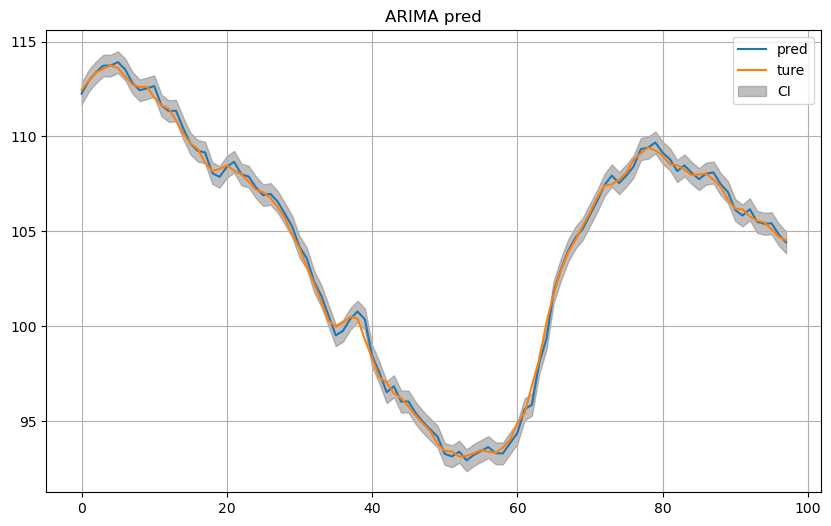

Mean Squared Error: 10.12998172752124
Mean CI: 0.5756308104858718


In [67]:
lower_bound_ARIMA = [arr[0] for arr in K_AR_y_pred_stock_CI]
upper_bound_ARIMA = [arr[1] for arr in K_AR_y_pred_stock_CI]

# ANN的預測與真值與CI
plt.figure(figsize=(10, 6))
plt.plot(K_AR_y_pred_stock, label='pred')
plt.plot(K_Linear_test_stock, label='ture')  #K_Linear_test_stock
plt.fill_between(range(len(mean_Bootstrap_data)), lower_bound_ARIMA, upper_bound_ARIMA, alpha=0.5, color='gray', label='CI')
plt.legend()
plt.title('ARIMA pred')
plt.grid(True)
plt.show()

mse = np.mean((mean_Bootstrap_data - testY)**2)
print(f'Mean Squared Error: {mse}')
print(f'Mean CI: {np.mean(np.array(upper_bound_ARIMA)-np.array(K_AR_y_pred_stock))}')

In [11]:
# 製造數據 non_Linear part
window_size = max(order)*10

X,Y = create_dataset(K_non_Linear_train_stock,window_size)
# print(X,Y)
testX = np.concatenate((Y[len(Y)-window_size:len(Y)], K_non_Linear_test_stock))
# print(testX)
testX_KF,testY = create_dataset(testX,window_size)
# print(testX_KF,testY)

# Bootstrap的詳細流程
(不能打亂，這樣會讓模型整個爛掉)

step1:我們先造假樣本，從原本的資料抽出N個資料點，有排序的，可以重複(抽出放回)

* 假設資料長度為500，那我們先從1到500抽出500個資料點，不放回

step2:對每一個假樣本用ANN建模

step3:將預測結果的平均當點預測，Z*(var/n)**0.5為CI的寬度

In [12]:
# 用ANN預測 non_Linear part
# Bootstrap
Bootstrap_data =[]
for B in range(config.Bootstrap):
    seed_everything(B)
    # 要先將資料重抽-------
    fakedata = K_non_Linear_train_stock.copy()  # 將訓練資料複製
    fakedata_n = np.random.choice(np.arange(len(fakedata)), size=int(len(fakedata)), replace= True) #選擇想要的編號
    fakedata_n = np.sort(fakedata_n) # 排序
    thefakedata = fakedata[fakedata_n]
    X,Y = create_dataset(thefakedata,window_size)
    #---------
    
    X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=B)
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
        tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
        tf.keras.layers.Dense(1)
    ])

    # 編譯模型
    model.compile(optimizer='adam', loss='mean_squared_error')

    # 訓練模型
    model.fit(X, Y, validation_data=(X_valid, Y_valid), epochs=50, verbose=0)

    # 在測試集上進行預測
    K_ANN_y_pred_stock = model.predict(testX_KF)

    # 預測結果
    Bootstrap_data.append(K_ANN_y_pred_stock[:,0])


4/4 [==============================] - 0s 667us/step


In [13]:
from scipy.stats import norm
mean_Bootstrap_data = sum(Bootstrap_data)/len(Bootstrap_data)
var_Bootstrap_data = sum((Bootstrap_data-mean_Bootstrap_data)**2)/(len(Bootstrap_data)-1)
# CI_Bootstrap_data = t.ppf(q=0.975, df=len(Bootstrap_data)-1)*((var_Bootstrap_data)**0.5) # 0.95CI的寬度
CI_Bootstrap_data = norm.ppf(0.975)*((var_Bootstrap_data)**0.5) # 0.95CI的寬度

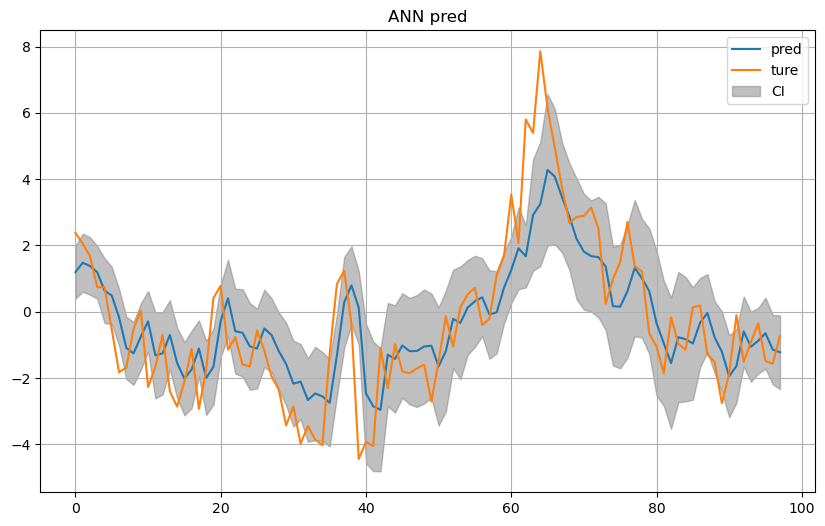

Mean Squared Error: 1.7870337213748269
Mean CI: 1.3872511386871338


In [14]:
upper_bound = mean_Bootstrap_data + CI_Bootstrap_data
lower_bound = mean_Bootstrap_data - CI_Bootstrap_data


# ANN的預測與真值與CI
plt.figure(figsize=(10, 6))
plt.plot(mean_Bootstrap_data, label='pred')
plt.plot(testY, label='ture')
plt.fill_between(range(len(mean_Bootstrap_data)), lower_bound, upper_bound, alpha=0.5, color='gray', label='CI')
plt.legend()
plt.title('ANN pred')
plt.grid(True)
plt.show()

mse = np.mean((mean_Bootstrap_data - testY)**2)
print(f'Mean Squared Error: {mse}')
print(f'Mean CI: {np.mean(CI_Bootstrap_data)}')

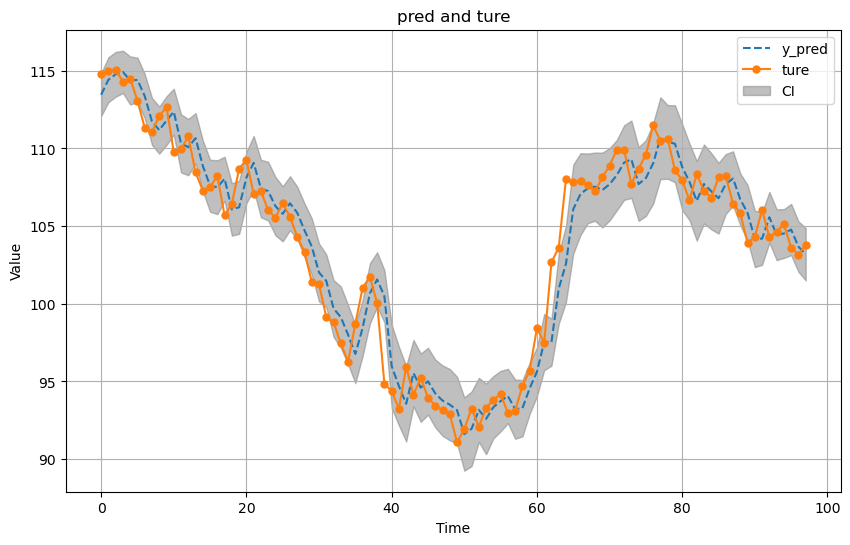

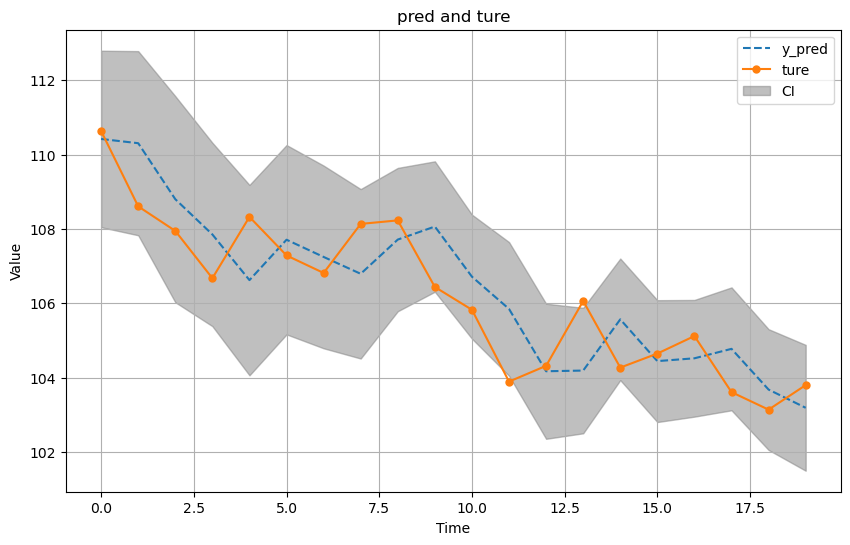

Mean Squared Error: 2.650721946225109


In [68]:
# 用ANN Bootstrap預測 non_Linear part
# mean_Bootstrap_data

# 預測結果
K_y_pred_stock = K_AR_y_pred_stock + mean_Bootstrap_data

all_upper_bound = upper_bound_ARIMA + upper_bound
all_lower_bound = lower_bound_ARIMA + lower_bound


plt.figure(figsize=(10, 6))
plt.plot(K_y_pred_stock, label='y_pred', linestyle='--')
plt.plot(test_stock, label='ture', marker='o', markersize=5)
plt.fill_between(range(len(mean_Bootstrap_data)), all_lower_bound, all_upper_bound, alpha=0.5, color='gray', label='CI')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 看最後20天
plt.figure(figsize=(10, 6))
plt.plot(K_y_pred_stock[len(K_y_pred_stock)-20:len(K_y_pred_stock)], label='y_pred', linestyle='--')
plt.plot(test_stock[len(test_stock)-20:len(test_stock)], label='ture', marker='o', markersize=5)
plt.fill_between(range(len(mean_Bootstrap_data))[0:20],
                 all_lower_bound[len(test_stock)-20:len(test_stock)],
                 all_upper_bound[len(test_stock)-20:len(test_stock)], alpha=0.5, color='gray', label='CI')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 評估模型性能
mse = np.mean((K_y_pred_stock - test_stock)**2)
print(f'Mean Squared Error: {mse}')

In [16]:
# 檢驗一下ANN到底有沒有幫助

# 預測結果
K_y_pred_stock = K_AR_y_pred_stock + mean_Bootstrap_data
# 評估模型性能
mse = np.mean((K_y_pred_stock - test_stock)**2)
print(f'Mean Squared Error: {mse}')

# 去掉ANN
mse2 = np.mean((K_AR_y_pred_stock - test_stock)**2)
print(f'去掉ANN的MSE: {mse2}')

Mean Squared Error: 2.64782582694621
去掉ANN的MSE: 6.614591771055039


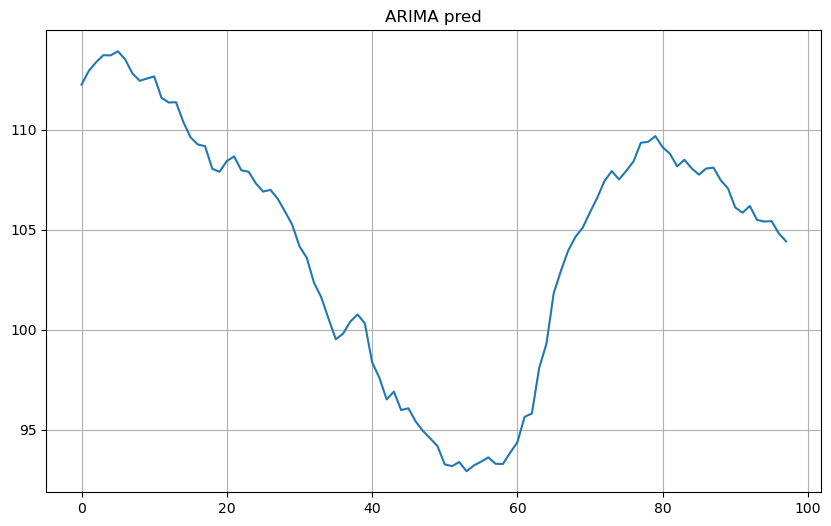

In [17]:
# ARIMA預測的結果
plt.figure(figsize=(10, 6))
plt.plot(K_AR_y_pred_stock)
plt.title('ARIMA pred')
plt.grid(True)
plt.show()

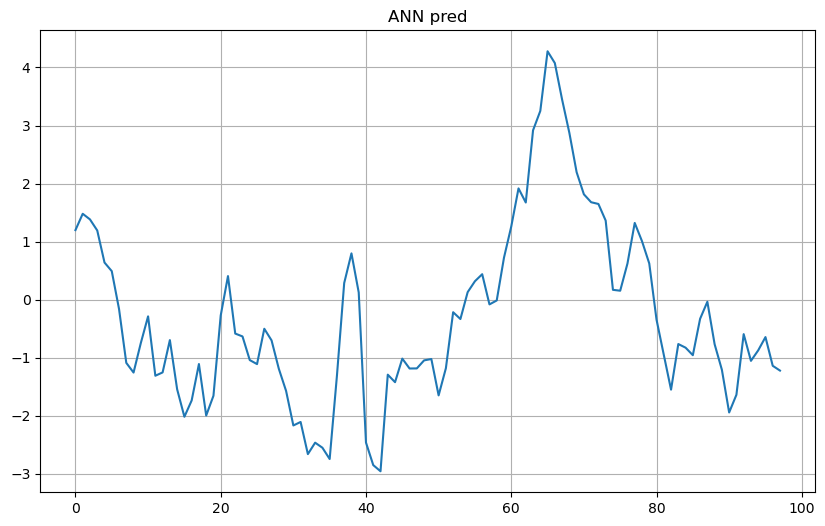

In [18]:
# ANN預測的結果
plt.figure(figsize=(10, 6))
plt.plot(mean_Bootstrap_data)
plt.title('ANN pred')
plt.grid(True)
plt.show()

Mean Squared Error: 2.64782582694621


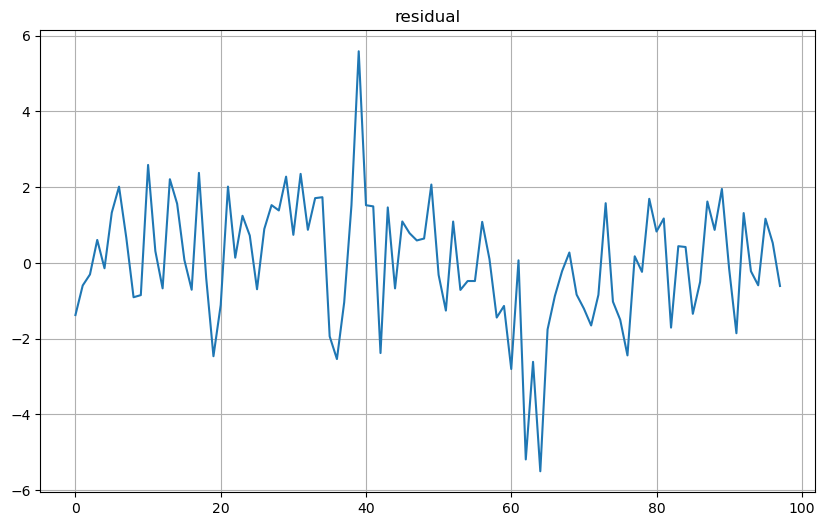

In [19]:
# residual
mse = np.mean((K_y_pred_stock - test_stock)**2)
print(f'Mean Squared Error: {mse}')

plt.figure(figsize=(10, 6))
plt.plot(K_y_pred_stock - test_stock)
plt.title('residual')
plt.grid(True)
plt.show()

---
# ANN
---
直接用ANN做的話

4/4 [==============================] - 0s 667us/step


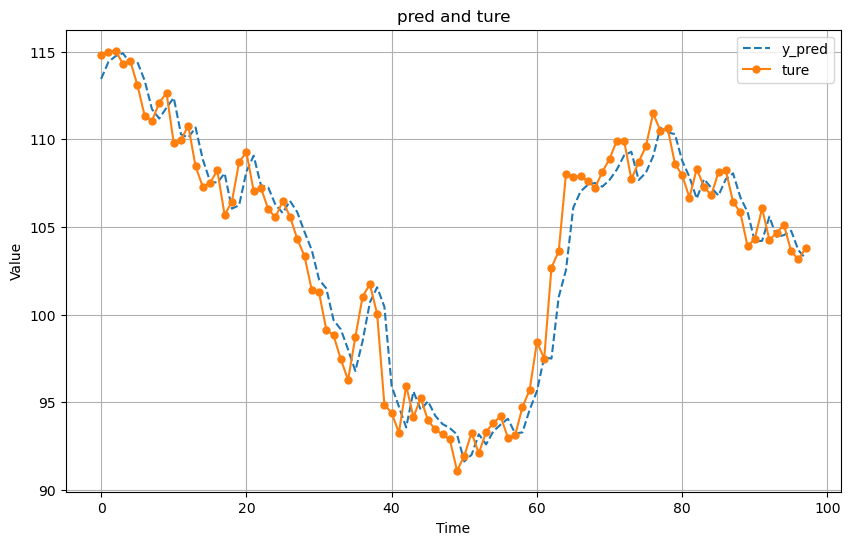

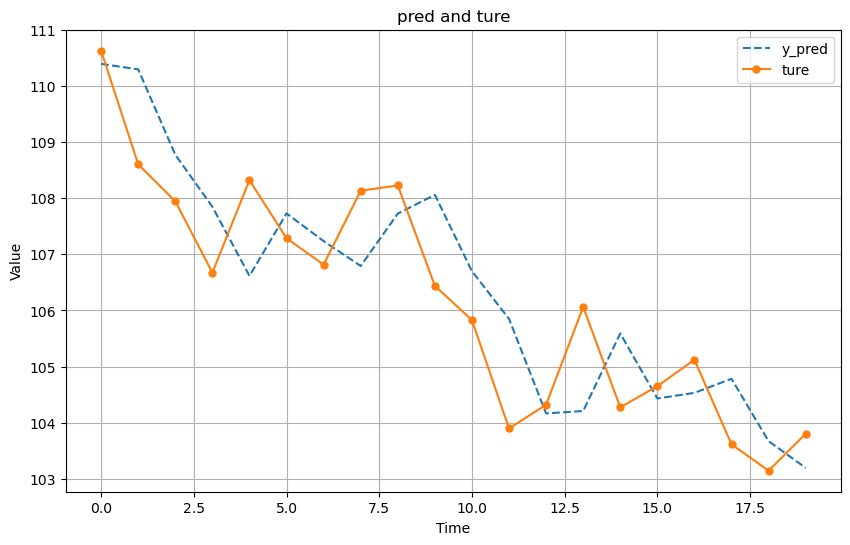

Mean Squared Error: 18.64484724410446


In [20]:
# 直接用ANN做的話
O_Linear_train_stock = df_stock[0:int(train_prob*len(df_stock))]
O_Linear_test_stock = df_stock[int(train_prob*len(df_stock)):len(df_stock)]

# 製造數據 non_Linear part
window_size = max(order)*10

X,Y = create_dataset(O_Linear_train_stock,window_size)
# print(X,Y)
testX = np.concatenate((Y[len(Y)-window_size:len(Y)], O_Linear_test_stock))
# print(testX)
testX,testY = create_dataset(testX,window_size)
# print(testX,testY)


# 用ANN預測 non_Linear part
seed_everything(config.seed)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dense(1)
])

# 編譯模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 訓練模型
model.fit(X, Y, epochs=50, verbose=0)

# 在測試集上進行預測
O_ANN_y_pred_stock = model.predict(testX)

# 預測結果
O_y_pred_stock = O_ANN_y_pred_stock[:,0]


plt.figure(figsize=(10, 6))
plt.plot(K_y_pred_stock, label='y_pred', linestyle='--')
plt.plot(test_stock, label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 看最後20天
plt.figure(figsize=(10, 6))
plt.plot(K_y_pred_stock[len(K_y_pred_stock)-20:len(K_y_pred_stock)], label='y_pred', linestyle='--')
plt.plot(test_stock[len(test_stock)-20:len(test_stock)], label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 評估模型性能
mse = np.mean((O_y_pred_stock - test_stock)**2)
print(f'Mean Squared Error: {mse}')

---
# MA_filter ARIMA-ANN model
---
## build MA_filter model
## dataset

In [21]:
# 切訓練測試
train_prob = config.train_prob
train_stock = df_stock[0:int(train_prob*len(df_stock))]
test_stock = df_stock[int(train_prob*len(df_stock)):len(df_stock)]

# 決定MA_fliter的長度
m = 0
bestK = -100
n_1 = config.n_1
long = len(df_stock)
for i in range(2,int(len(train_stock)*n_1)):
    y_tr = MA_filter(train_stock,i)  #ma
    kurtosis_value = kurtosis(y_tr)
    # print(kurtosis_value,len(y_tr))
    if abs(3-kurtosis_value)<abs(3-bestK):
        bestK = kurtosis_value
        m = i

print(f"峰度為：{bestK}, m為:{m}, 最大值m為:{int(len(train_stock)*n_1)}")

峰度為：1.1620925547803278, m為:18, 最大值m為:19


In [22]:
# Linear
Linear_df_stock = MA_filter(df_stock,m)
# non_Linear
non_Linear_df_stock = df_stock[m-1:long] - Linear_df_stock

# 切訓練測試，以len(test_stock)為主
train_prob = config.train_prob

Linear_train_stock = Linear_df_stock[0:len(Linear_df_stock)-len(test_stock)]
Linear_test_stock = Linear_df_stock[len(Linear_df_stock)-len(test_stock):len(Linear_df_stock)]

non_Linear_train_stock = non_Linear_df_stock[0:len(Linear_df_stock)-len(test_stock)]    
non_Linear_test_stock = non_Linear_df_stock[len(Linear_df_stock)-len(test_stock):len(Linear_df_stock)]


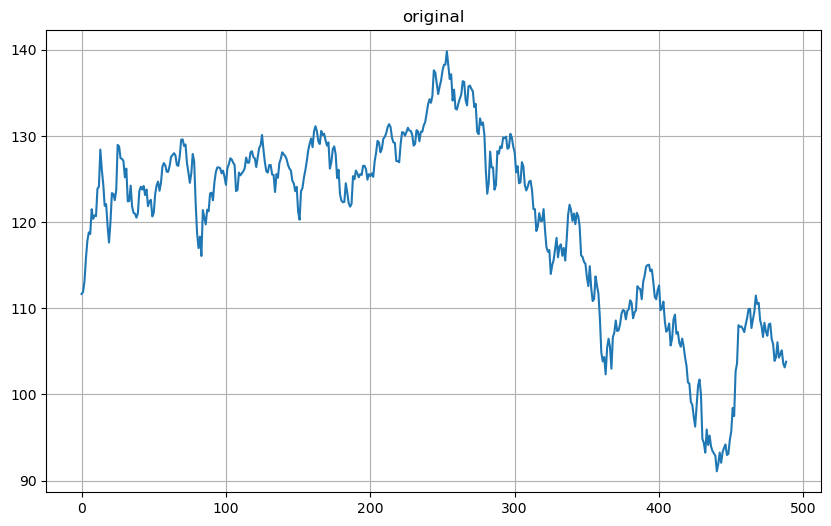

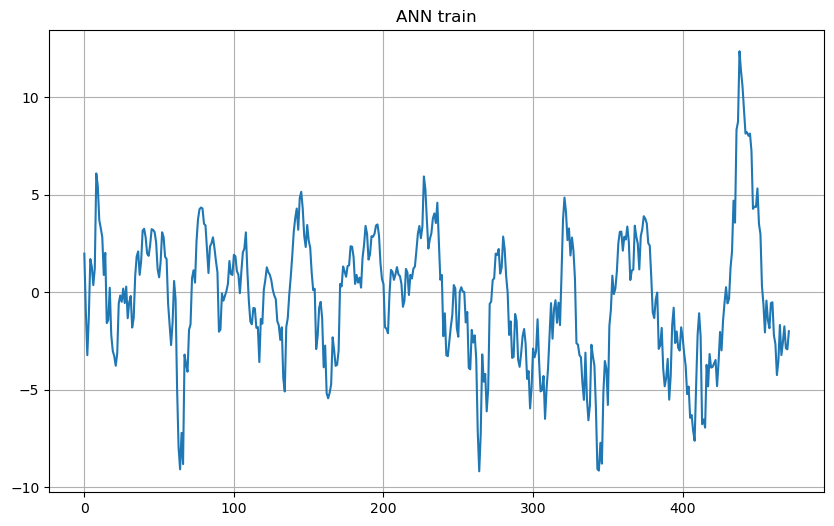

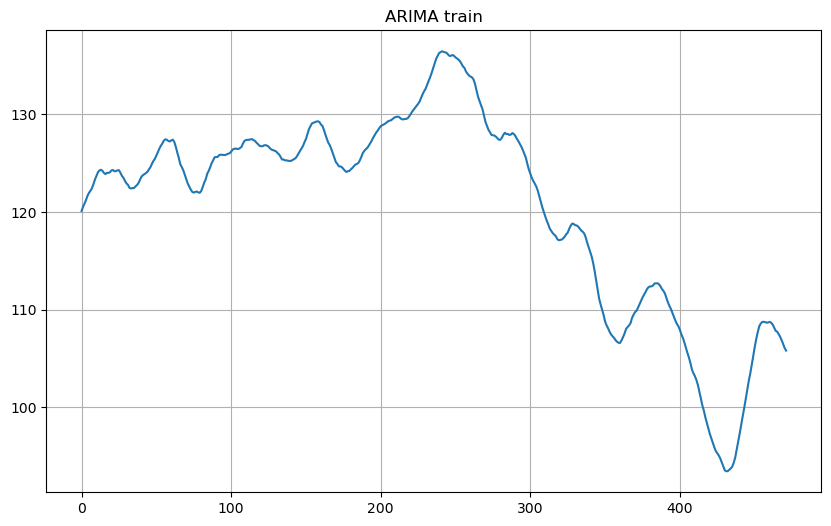

In [23]:
# 檢查丟入ANN的數據 以及綠波過後的數據
plt.figure(figsize=(10, 6))
plt.plot(df_stock)
plt.title('original')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(non_Linear_df_stock)
plt.title('ANN train')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(Linear_df_stock)
plt.title('ARIMA train')
plt.grid(True)
plt.show()

# 用ARIMA預測 Linear part選擇期數

In [24]:
def find_order(dataset):
    # p，q取太大的話會出現 LinAlgError: LU decomposition error.
    p_range = range(0, 5)  # AR
    q_range = range(0, 5)  # MA

    best_aic = np.inf
    best_params = None

    # 進行參數搜索
    for p in p_range:
        for q in q_range:
            # print(p,q)
            if p or q != 0:
                model = ARIMA(dataset, order=(p, 0, q))
                results = model.fit()
                aic = results.aic
                if aic < best_aic:
                    best_aic = aic
                    best_params = (p, q)

    return best_params

# 用Linear_train_stock找期數

order = find_order(Linear_train_stock)
order

C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: M

(4, 3)

In [25]:
# 用ARIMA預測 Linear part
AR_y_pred = []
for i in range(0, len(test_stock)):
    train = np.concatenate((Linear_train_stock, Linear_test_stock[0:i]))
    ARmodel =  ARIMA(train, order =(order[0], 0, order[1]))
    result = ARmodel.fit()
    AR_y_pred.append(result.get_forecast(1).predicted_mean[0])

C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: M

C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: M

C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\banana\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: M

In [26]:
result.get_forecast(1).conf_int()

array([[105.43426523, 105.85930809]])

4/4 [==============================] - 0s 667us/step


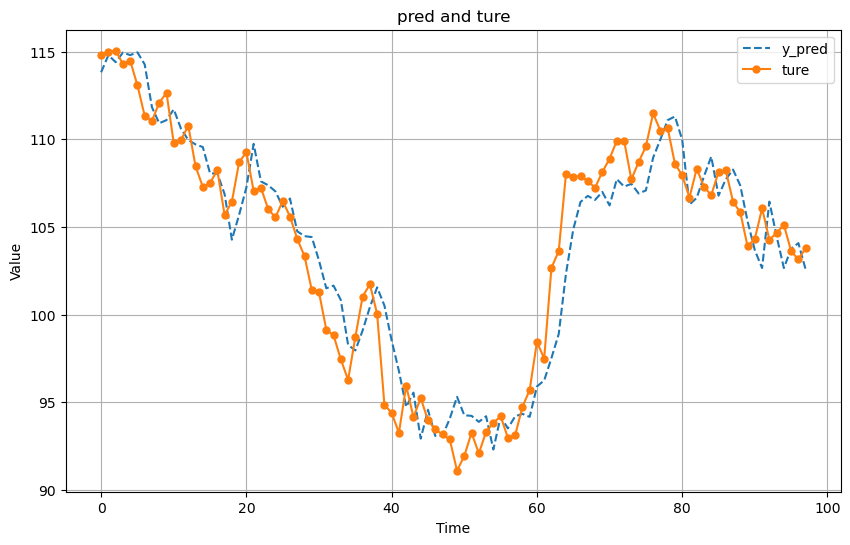

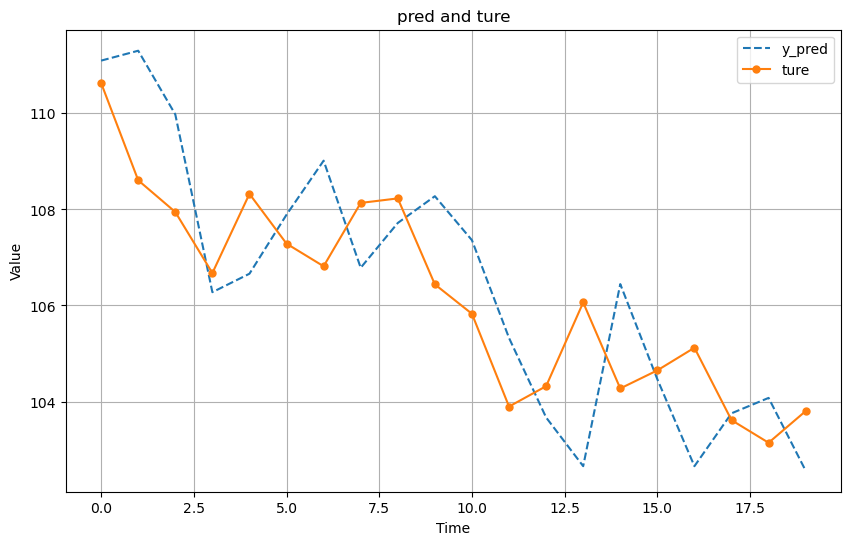

Mean Squared Error: 4.214498325906255


In [27]:

# 製造數據 non_Linear part
window_size = max(order)*5
X,Y = create_dataset(non_Linear_train_stock,window_size)
# print(X,Y)
testX = np.concatenate((Y[len(Y)-window_size:len(Y)], non_Linear_test_stock))
# print(testX)
testX,testY = create_dataset(testX,window_size)
# print(testX,testY)
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=config.seed)

# 用ANN預測 non_Linear part
seed_everything(config.seed)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dense(1)
])

# 編譯模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 訓練模型
model.fit(X_train, Y_train, epochs=50, validation_data=(X_valid, Y_valid), verbose=0)

# 在測試集上進行預測
ANN_y_pred = model.predict(testX)

# 預測結果
y_pred_stock = AR_y_pred + ANN_y_pred[:,0]


plt.figure(figsize=(10, 6))
plt.plot(y_pred_stock, label='y_pred', linestyle='--')
plt.plot(test_stock, label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 看最後20天
plt.figure(figsize=(10, 6))
plt.plot(y_pred_stock[len(y_pred_stock)-20:len(y_pred_stock)], label='y_pred', linestyle='--')
plt.plot(test_stock[len(test_stock)-20:len(test_stock)], label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 評估模型性能
mse = np.mean((y_pred_stock - test_stock)**2)
print(f'Mean Squared Error: {mse}')

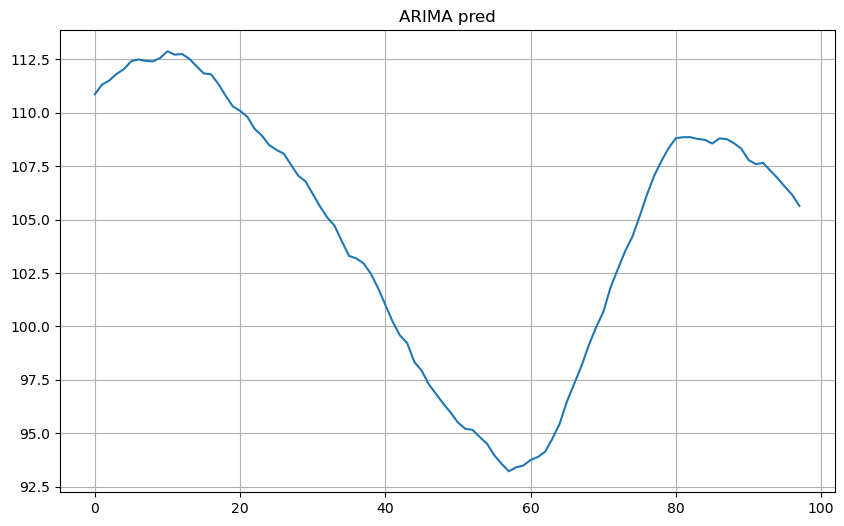

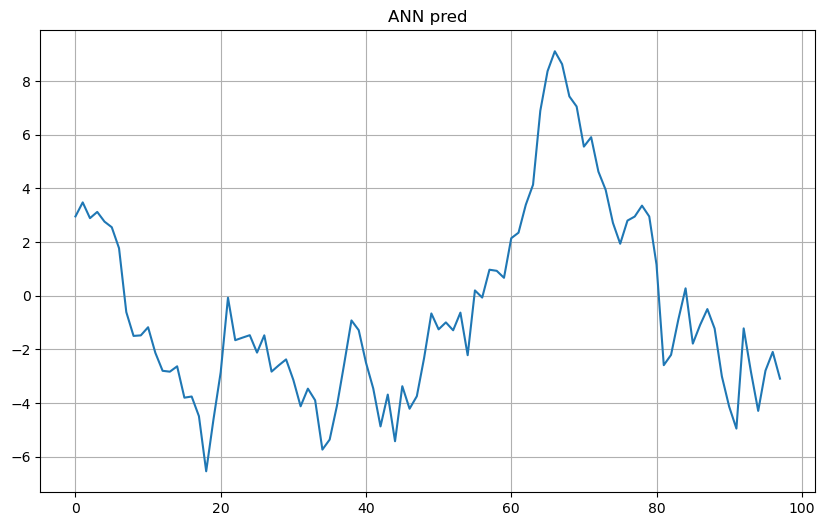

Mean Squared Error: 20.994259912613067


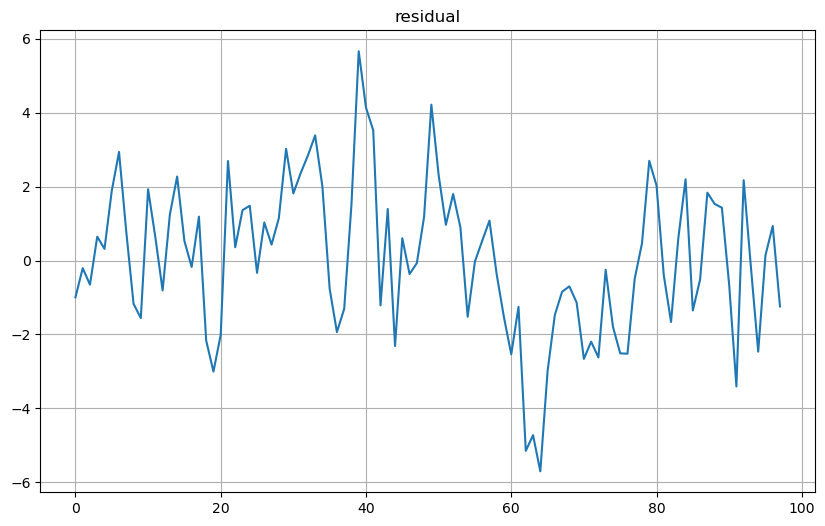

In [28]:
# ARIMA預測的結果
plt.figure(figsize=(10, 6))
plt.plot(AR_y_pred)
plt.title('ARIMA pred')
plt.grid(True)
plt.show()

# ANN預測的結果
plt.figure(figsize=(10, 6))
plt.plot(ANN_y_pred[:,0])
plt.title('ANN pred')
plt.grid(True)
plt.show()

# residual
mse = np.mean((AR_y_pred - test_stock)**2)
print(f'Mean Squared Error: {mse}')

plt.figure(figsize=(10, 6))
plt.plot(y_pred_stock - test_stock)
plt.title('residual')
plt.grid(True)
plt.show()

In [69]:
1

1